In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor as GPR, kernels
#from sklearn.gaussian_process import 
from astroML.datasets import generate_mu_z

(35.0, 50.0)

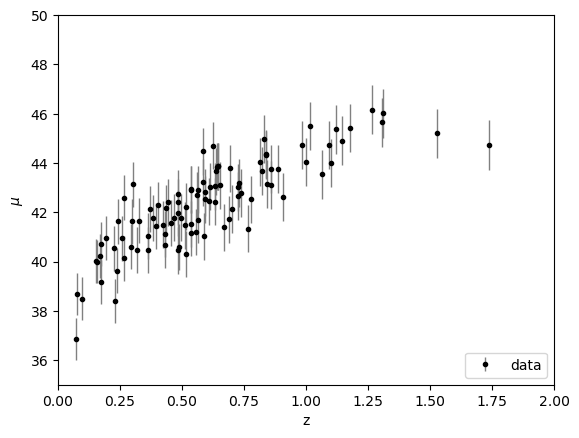

In [43]:
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) ###YOU CAN'T CHANGE THIS
x = z_sample.reshape(-1,1)
y = mu_sample

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

In [50]:
l=1 #length scale

In [76]:
my_kernel = kernels.RBF(length_scale=l) #, length_scale_bounds=[1e-30, 100]

In [77]:
gpr = GPR(kernel=my_kernel, random_state=0)
gpr.fit(x, y)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


GaussianProcessRegressor(kernel=RBF(length_scale=1), random_state=0)

In [79]:
test = np.linspace(0, 1.75, 1000).reshape(-1,1)
f, f_err = gpr.predict(test, return_std=True)

#print (f)

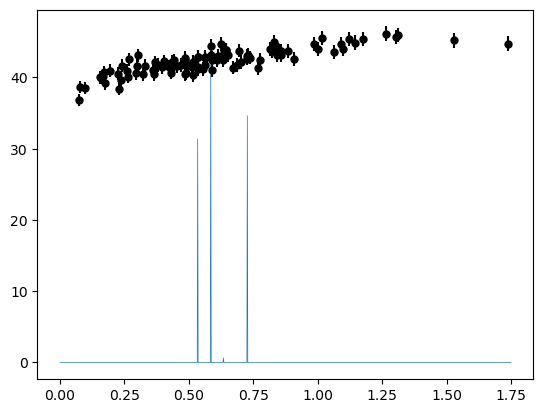

In [80]:
#plt.scatter (x, y, c='black', s=10)
plt.errorbar(x, y, yerr=dmu, fmt='.k', ms=10) #, c='black'
plt.plot(test, f, linewidth=0.5, label='prediction') #, c='red'
#plt.fill_betweenx(np.linspace(0, 1.75, 1000), f-f_err, f+f_err, color='grey')
plt.show()
